In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

# Görselleştirme ayarları
%matplotlib inline
sns.set(style="whitegrid")

In [96]:
# CSV dosyasını oku (Dosya isminin doğru olduğundan emin ol)
df = pd.read_excel('preprocessed_data.xlsx')

# İlk 5 satıra ve veri tiplerine bak
print(f"Veri Seti Boyutu: {df.shape}")
display(df.head())

Veri Seti Boyutu: (76, 58)


,City,"Meal, Inexpensive Restaurant","Meal for 2 People, Mid-range Restaurant, Three-course",McMeal at McDonalds (or Equivalent Combo Meal),Domestic Beer (0.5 liter draught),Imported Beer (0.33 liter bottle),Imported Beer (0.33 liter bottle).1,Cappuccino (regular),Coke/Pepsi (0.33 liter bottle),Water (0.33 liter bottle),"Milk (regular), (1 liter)",Loaf of Fresh White Bread (500g),"Rice (white), (1kg)",Eggs (regular) (12),Local Cheese (1kg),Chicken Fillets (1kg),Beef Round (1kg) (or Equivalent Back Leg Red Meat),Apples (1kg),Banana (1kg),Oranges (1kg),Tomato (1kg),Potato (1kg),Onion (1kg),Lettuce (1 head),Water (1.5 liter bottle),Bottle of Wine (Mid-Range),Domestic Beer (0.5 liter bottle),Imported Beer (0.33 liter bottle).2,Imported Beer (0.33 liter bottle).3,Cigarettes 20 Pack (Marlboro),One-way Ticket (Local Transport),Monthly Pass (Regular Price),Taxi Start (Normal Tariff),Taxi 1km (Normal Tariff),Taxi 1hour Waiting (Normal Tariff),Gasoline (1 liter),Volkswagen Golf 1.4 90 KW Trendline (Or Equivalent New Car),Toyota Corolla Sedan 1.6l 97kW Comfort (Or Equivalent New Car),"Basic (Electricity, Heating, Cooling, Water, Garbage) for 85m2 Apartment",Mobile Phone Monthly Plan with Calls and 10GB+ Data,"Internet (60 Mbps or More, Unlimited Data, Cable/ADSL)","Fitness Club, Monthly Fee for 1 Adult",Tennis Court Rent (1 Hour on Weekend),"Cinema, International Release, 1 Seat","Preschool (or Kindergarten), Full Day, Private, Monthly for 1 Child","International Primary School, Yearly for 1 Child",1 Pair of Jeans (Levis 501 Or Similar),"1 Summer Dress in a Chain Store (Zara, H&M, ...)",1 Pair of Nike Running Shoes (Mid-Range),1 Pair of Men Leather Business Shoes,Apartment (1 bedroom) in City Centre,Apartment (1 bedroom) Outside of Centre,Apartment (3 bedrooms) in City Centre,Apartment (3 bedrooms) Outside of Centre,Price per Square Meter to Buy Apartment in City Centre,Price per Square Meter to Buy Apartment Outside of Centre,Average Monthly Net Salary (After Tax),"Mortgage Interest Rate in Percentages (%), Yearly, for 20 Years Fixed-Rate"
0,Adana,250.0,900.0,210.0,90.0,122.0,119.0,92.0,40.0,15.0,25.0,41.0,64.0,42.0,383.0,179.0,632.0,19.0,75.0,30.0,41.0,16.0,14.0,39.0,6.0,259.0,63.0,122.0,119.0,63.0,20.0,488.0,31.0,22.0,254.0,37.0,1685000.0,1425333.0,2766.0,275.0,313.0,942.0,344.0,125.0,8360.0,152675.0,1366.0,1416.0,2040.0,1680.0,10474.0,7075.0,15968.0,10969.0,47618.0,34013.0,24287.0,28.25
1,Adiyaman,250.0,900.0,210.0,90.0,122.0,119.0,92.0,40.0,15.0,25.0,41.0,64.0,42.0,437.0,179.0,632.0,19.0,75.0,30.0,41.0,16.0,14.0,39.0,8.0,258.0,63.0,122.0,119.0,67.0,NaN,NaN,31.0,22.0,254.0,37.0,2715560.0,NaN,2885.0,295.0,313.0,300.0,NaN,262.0,8357.0,152629.0,1723.0,1588.0,2038.0,1678.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.25
2,Afyon,100.0,500.0,150.0,75.0,75.0,70.0,75.0,15.0,5.0,27.0,37.0,55.0,44.0,250.0,150.0,400.0,20.0,45.0,26.0,22.0,20.0,18.0,25.0,11.0,150.0,63.0,75.0,70.0,64.0,11.0,NaN,29.0,25.0,100.0,40.0,1000000.0,1500000.0,1500.0,225.0,350.0,500.0,NaN,150.0,13845.0,197031.0,1250.0,550.0,3254.0,3444.0,3000.0,6000.0,12500.0,9000.0,NaN,NaN,17001.0,21.14
3,Agri,90.0,NaN,180.0,NaN,NaN,NaN,NaN,24.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Amasya,250.0,525.0,235.0,80.0,90.0,40.0,70.0,30.0,10.0,26.0,30.0,40.0,41.0,185.0,115.0,300.0,25.0,31.0,19.0,30.0,19.0,12.0,15.0,7.0,250.0,30.0,90.0,40.0,59.0,15.0,450.0,25.0,20.0,80.0,38.0,1000000.0,1000000.0,2008.0,260.0,350.0,2000.0,200.0,95.0,3500.0,250000.0,600.0,600.0,1500.0,1500.0,13500.0,10000.0,24000.0,18500.0,15700.0,13000.0,11202.0,30.00


In [97]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

#df

In [ ]:
# Kolon bazında eksik veri yüzdesini hesapla
missing_ratio_cols = df.isnull().mean(axis=0)

# %25 ve üzeri boş olan kolonları sil
col_threshold = 0.25
df_cleaned = df.loc[:, missing_ratio_cols < col_threshold]

print(f"Silinen kolon sayısı: {len(missing_ratio_cols) - df_cleaned.shape[1]}")



Silinen kolon sayısı: 43


In [99]:
df_cleaned

,City,"Meal, Inexpensive Restaurant",McMeal at McDonalds (or Equivalent Combo Meal),Domestic Beer (0.5 liter draught),Imported Beer (0.33 liter bottle),Cappuccino (regular),Coke/Pepsi (0.33 liter bottle),"Milk (regular), (1 liter)",Eggs (regular) (12),Water (1.5 liter bottle),Imported Beer (0.33 liter bottle).2,Gasoline (1 liter),"Basic (Electricity, Heating, Cooling, Water, Garbage) for 85m2 Apartment",Mobile Phone Monthly Plan with Calls and 10GB+ Data,"Internet (60 Mbps or More, Unlimited Data, Cable/ADSL)"
0,Adana,250.0,210.0,90.0,122.0,92.0,40.0,25.0,42.0,6.0,122.0,37.0,2766.0,275.0,313.0
1,Adiyaman,250.0,210.0,90.0,122.0,92.0,40.0,25.0,42.0,8.0,122.0,37.0,2885.0,295.0,313.0
2,Afyon,100.0,150.0,75.0,75.0,75.0,15.0,27.0,44.0,11.0,75.0,40.0,1500.0,225.0,350.0
3,Agri,90.0,180.0,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Amasya,250.0,235.0,80.0,90.0,70.0,30.0,26.0,41.0,7.0,90.0,38.0,2008.0,260.0,350.0
5,Ankara,250.0,250.0,120.0,140.0,88.0,41.0,35.0,58.0,12.0,140.0,42.0,2325.0,297.0,380.0
6,Antalya,275.0,300.0,120.0,125.0,98.0,43.0,30.0,53.0,11.0,125.0,40.0,2312.0,321.0,401.0
7,Artvin,100.0,137.0,70.0,87.0,52.0,25.0,NaN,NaN,NaN,87.0,NaN,NaN,NaN,NaN
8,Aydin,250.0,225.0,75.0,100.0,86.0,29.0,33.0,48.0,10.0,100.0,39.0,1982.0,190.0,308.0
9,Balikesir,250.0,195.0,75.0,80.0,80.0,20.0,29.0,50.0,11.0,80.0,37.0,2000.0,381.0,362.0


In [ ]:
# Satır bazında eksik veri yüzdesini hesapla
missing_ratio = df_cleaned.isnull().mean(axis=1)

# Verisinin %40'ından fazlası boş olan şehirleri listeden çıkar
threshold = 0.40
df_cleaned = df_cleaned[missing_ratio < threshold].copy()

print(f"Silinen şehir sayısı: {len(df) - len(df_cleaned)}")
# Şehir ismini (string) sayısal işlemlerden ayırmak için index yapalım
df_cleaned.set_index('City', inplace=True)

Silinen şehir sayısı: 20


In [101]:
df_cleaned

,"Meal, Inexpensive Restaurant",McMeal at McDonalds (or Equivalent Combo Meal),Domestic Beer (0.5 liter draught),Imported Beer (0.33 liter bottle),Cappuccino (regular),Coke/Pepsi (0.33 liter bottle),"Milk (regular), (1 liter)",Eggs (regular) (12),Water (1.5 liter bottle),Imported Beer (0.33 liter bottle).2,Gasoline (1 liter),"Basic (Electricity, Heating, Cooling, Water, Garbage) for 85m2 Apartment",Mobile Phone Monthly Plan with Calls and 10GB+ Data,"Internet (60 Mbps or More, Unlimited Data, Cable/ADSL)"
City,,,,,,,,,,,,,,
Adana,250.0,210.0,90.0,122.0,92.0,40.0,25.0,42.0,6.0,122.0,37.0,2766.0,275.0,313.0
Adiyaman,250.0,210.0,90.0,122.0,92.0,40.0,25.0,42.0,8.0,122.0,37.0,2885.0,295.0,313.0
Afyon,100.0,150.0,75.0,75.0,75.0,15.0,27.0,44.0,11.0,75.0,40.0,1500.0,225.0,350.0
Amasya,250.0,235.0,80.0,90.0,70.0,30.0,26.0,41.0,7.0,90.0,38.0,2008.0,260.0,350.0
Ankara,250.0,250.0,120.0,140.0,88.0,41.0,35.0,58.0,12.0,140.0,42.0,2325.0,297.0,380.0
Antalya,275.0,300.0,120.0,125.0,98.0,43.0,30.0,53.0,11.0,125.0,40.0,2312.0,321.0,401.0
Aydin,250.0,225.0,75.0,100.0,86.0,29.0,33.0,48.0,10.0,100.0,39.0,1982.0,190.0,308.0
Balikesir,250.0,195.0,75.0,80.0,80.0,20.0,29.0,50.0,11.0,80.0,37.0,2000.0,381.0,362.0
Bilecik,350.0,254.0,145.0,180.0,110.0,48.0,36.0,63.0,13.0,180.0,42.0,1936.0,338.0,437.0


In [102]:
# Sayısal verileri seç
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns

# Medyan ile doldurma işlemi
imputer = SimpleImputer(strategy='median')
df_filled = pd.DataFrame(imputer.fit_transform(df_cleaned[numeric_cols]), 
                         columns=numeric_cols, 
                         index=df_cleaned.index)

print("Eksik veriler başarıyla dolduruldu.")

Eksik veriler başarıyla dolduruldu.


In [103]:
df_filled.shape

(56, 14)

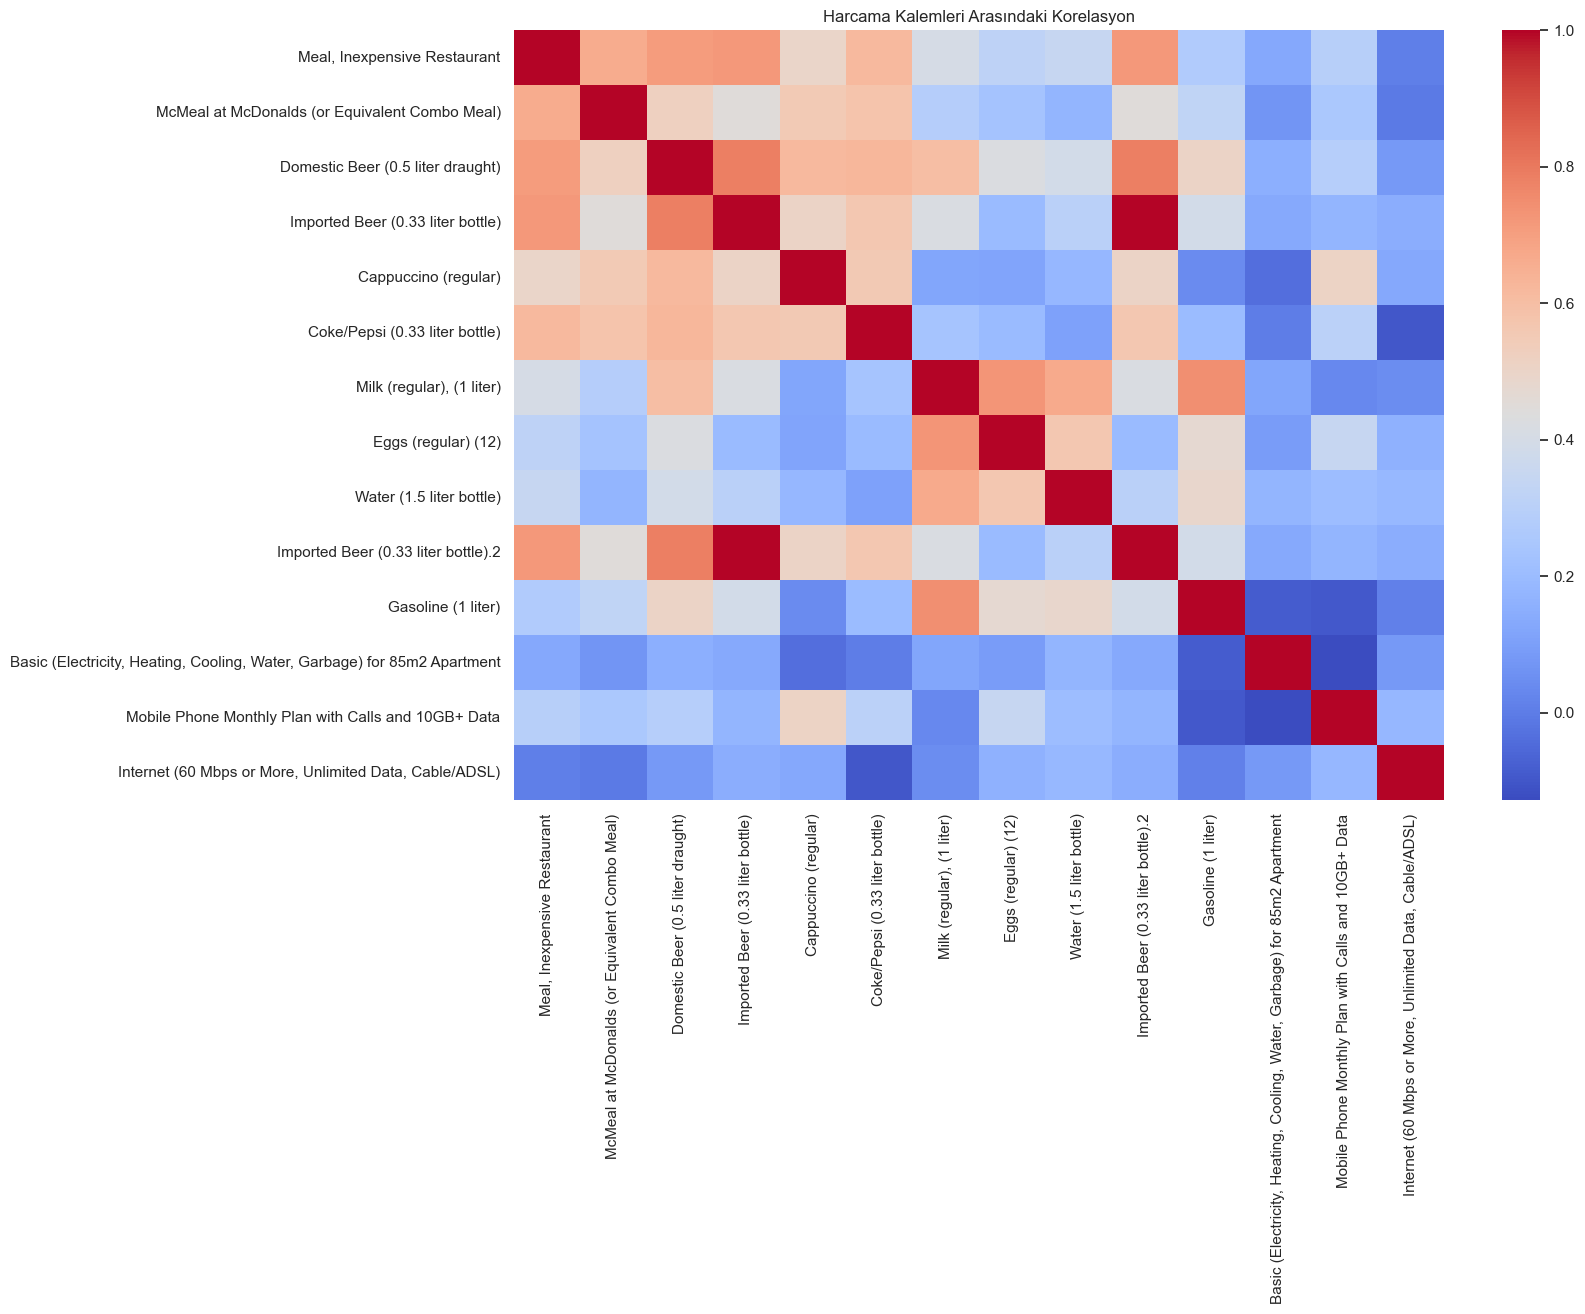

In [104]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_filled.corr(), annot=False, cmap='coolwarm')
plt.title("Harcama Kalemleri Arasındaki Korelasyon")
plt.show()

In [105]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_filled)

# Ölçeklenmiş veriyi DataFrame yapalım
df_scaled = pd.DataFrame(scaled_data, columns=numeric_cols, index=df_filled.index)

In [106]:
# Modeli kur ve çalıştır
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df_filled['Cluster'] = kmeans.fit_predict(scaled_data)

# Her kümede kaç şehir var bakalım
print(df_filled['Cluster'].value_counts())

Cluster
4    18
1    14
3    10
2    10
0     4
Name: count, dtype: int64


In [107]:
# Küme bazlı ortalama maliyetleri hesapla (Sıralama için)
# Örnek olarak 'Apartment (1 bedroom) in City Centre' sütununu veya tüm sütunların ortalamasını kullanabilirsin
cluster_order = df_filled.groupby('Cluster').mean().mean(axis=1).sort_values().index

# İsim haritası oluştur
mapping = {
    cluster_order[0]: "Çok Ucuz",
    cluster_order[1]: "Ucuz",
    cluster_order[2]: "Orta",
    cluster_order[3]: "Pahalı",
    cluster_order[4]: "Çok Pahalı"
}

df_filled['Cost_Category'] = df_filled['Cluster'].map(mapping)

# Sonucu göster
display(df_filled[['Cost_Category']].sort_values(by='Cost_Category'))

,Cost_Category
City,
Isparta,Orta
Yalova,Orta
Karaman,Orta
Usak,Orta
Adana,Pahalı
Manisa,Pahalı
Sakarya,Pahalı
Samsun,Pahalı
Tekirdag,Pahalı


In [ ]:
%pip install geopandas

In [120]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# 1. Senin verdiğin linkin "Raw" (Ham) hali
url = "https://raw.githubusercontent.com/cihadturhan/tr-geojson/master/geo/tr-cities-utf8.json"

try:
    # Veriyi çekiyoruz
    turkiye_map = gpd.read_file(url)
    print("Harita verisi başarıyla yüklendi.")
except Exception as e:
    print(f"Veri çekilirken hata oluştu: {e}")

# 2. İsim Eşleştirme Sözlüğü (CSV'deki isimler -> Haritadaki isimler)
# Bu liste senin CSV'deki yazımlara göre en kritik adımdır.
name_mapping = {
    # Karakter Düzeltmeleri
    'Istanbul': 'İstanbul', 'Izmir': 'İzmir', 'Aydin': 'Aydın', 
    'Balikesir': 'Balıkesir', 'Bartin': 'Bartın', 'Canakkale': 'Çanakkale', 
    'Corum': 'Çorum', 'Diyarbakir': 'Diyarbakır', 'Duzce': 'Düzce', 
    'Eskisehir': 'Eskişehir', 'Kahramanmaras': 'Kahramanmaraş', 
    'Karabuk': 'Karabük', 'Kirikkale': 'Kırıkkale', 'Kirklareli': 'Kırklareli', 
    'Kirsehir': 'Kırşehir', 'Kutahya': 'Kütahya', 'Mugla': 'Muğla', 
    'Nevsehir': 'Nevşehir', 'Nigde': 'Niğde', 'Sanliurfa': 'Şanlıurfa', 
    'Tekirdag': 'Tekirdağ', 'Usak': 'Uşak', 'Adiyaman': 'Adıyaman',
    
    # Tam İsim Düzeltmeleri
    'Afyon': 'Afyonkarahisar',
    
    # Bunlar genelde aynıdır ama garantiye alalım (UTF-8 uyumu için)
    'Kocaeli': 'Kocaeli', 'Gaziantep': 'Gaziantep', 'Sakarya': 'Sakarya',
    'Samsun': 'Samsun', 'Trabzon': 'Trabzon', 'Denizli': 'Denizli',
    'Konya': 'Konya', 'Bursa': 'Bursa', 'Burdur': 'Burdur', 'Bolu': 'Bolu',
    'Amasya': 'Amasya', 'Kilis': 'Kilis', 'Aksaray': 'Aksaray', 'Kayseri': 'Kayseri',
    'Giresun': 'Giresun', 'Antalya': 'Antalya', 'Ankara': 'Ankara', 
    'Yozgat': 'Yozgat', 'Kastamonu': 'Kastamonu', 'Bilecik': 'Bilecik',
    'Batman': 'Batman', 'Edirne': 'Edirne', 'Osmaniye': 'Osmaniye',
    'Tokat': 'Tokat', 'Sivas': 'Sivas', 'Malatya': 'Malatya', 'Manisa': 'Manisa',
    'Isparta': 'Isparta', 'Yalova': 'Yalova', 'Karaman': 'Karaman', 'Zonguldak': 'Zonguldak'
}

# Veri setindeki index isimlerini güncelle
df_final = df_filled.copy()
df_final.index = df_final.index.map(lambda x: name_mapping.get(x, x))

# 3. Harita ile Veriyi Birleştir
# Bu GeoJSON'da şehir isimleri 'name' sütununda bulunuyor.
merged = turkiye_map.merge(df_final, left_on='name', right_index=True, how='left')

Harita verisi başarıyla yüklendi.


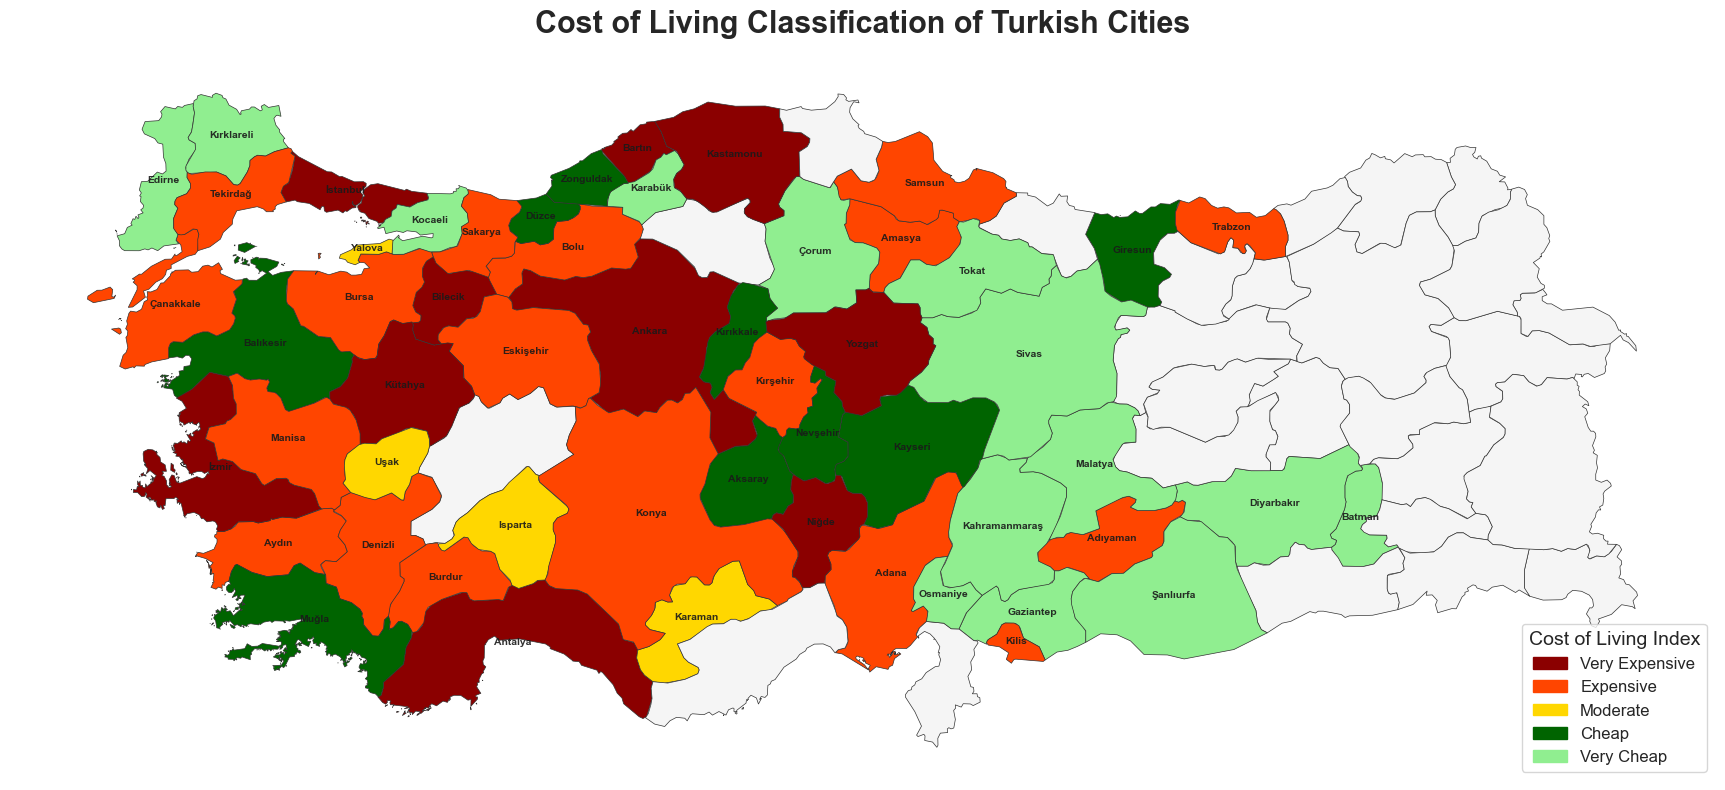

The map has been successfully saved.


In [129]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. English Category Names & Professional Colors
# Sol taraftaki anahtarlar df_filled içindeki kategorilerin aynısı olmalı
color_map = {
    "Çok Pahalı": {"label": "Very Expensive", "color": "#8b0000"},
    "Pahalı":     {"label": "Expensive",      "color": "#ff4500"},
    "Orta":       {"label": "Moderate",       "color": "#ffd700"},
    "Ucuz":       {"label": "Cheap",          "color": "#006400"},
    "Çok Ucuz":   {"label": "Very Cheap",     "color": "#90ee90"}
}

fig, ax = plt.subplots(1, 1, figsize=(22, 11))

# 2. Plotting the Map
# merged['Cost_Category'] içindeki Türkçe isimleri kullanarak renkleri alıyoruz
merged.plot(ax=ax, 
            missing_kwds={'color': "#262525"}, 
            edgecolor='#333333', 
            linewidth=0.5,
            color=[color_map.get(cat, {"color": "#f5f5f5"})["color"] for cat in merged['Cost_Category']])

# 3. Printing City Names (Preserving Turkish Characters)
for idx, row in merged.iterrows():
    centroid = row.geometry.centroid
    if pd.notnull(row['Cost_Category']):
        ax.text(centroid.x, centroid.y, row['name'], 
                fontsize=7.5, 
                ha='center', 
                fontweight='bold', 
                color='#1a1a1a', 
                alpha=0.9)

# 4. English Legend Construction
legend_handles = [
    mpatches.Patch(color=val["color"], label=val["label"]) 
    for val in color_map.values()
]

plt.legend(handles=legend_handles, 
           title="Cost of Living Index", 
           loc="lower right", 
           fontsize=12, 
           title_fontsize=14,
           frameon=True,
           facecolor='white')

# 5. English Title
plt.title('Cost of Living Classification of Turkish Cities', fontsize=22, pad=20, fontweight='bold')
ax.axis('off')

# 6. Save as High-Quality JPG
plt.savefig("turkey_cost_of_living_english.jpg", dpi=300, format='jpg', bbox_inches='tight')

plt.show()

print("The map has been successfully saved.")